# Step 2: Physics-Informed Neural Network (PINN) - The Brain
## Building and training the neural network for temperature prediction

In [1]:
import os
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import warnings
warnings.filterwarnings('ignore')

from pinn_physics import wrap_pinn, build_pinn_model, PhysicsInformedModel


In [2]:
# Check TensorFlow version
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.20.0
GPU available: []


## Load prepared data

In [3]:
# Load training data (from prepare_data.py — real locations + time hold-outs)
X_train = np.load('X_train.npy')
y_train = np.load('y_train.npy')

# Prefer explicit val/test arrays when present
if os.path.exists('X_val.npy'):
    X_val = np.load('X_val.npy')
    y_val = np.load('y_val.npy')
    print(f'X_val   shape: {X_val.shape}')
if os.path.exists('X_test.npy'):
    X_test = np.load('X_test.npy')
    y_test = np.load('y_test.npy')
    print(f'X_test  shape: {X_test.shape}')
if os.path.exists('X_loc_holdout.npy'):
    X_loc_holdout = np.load('X_loc_holdout.npy')
    y_loc_holdout = np.load('y_loc_holdout.npy')
    print(f'X_loc   shape: {X_loc_holdout.shape}')

print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')


X_val   shape: (2010, 3)
X_test  shape: (2010, 3)
X_loc   shape: (4019, 3)
X_train shape: (16075, 3)
y_train shape: (16075, 1)


In [4]:
# Load scalers
with open('scalers.pkl', 'rb') as f:
    scalers = pickle.load(f)
    
scaler_lat = scalers['scaler_lat']
scaler_lon = scalers['scaler_lon']
scaler_time = scalers['scaler_time']
scaler_temp = scalers['scaler_temp']
scaler_dhw = scalers['scaler_dhw']

print("Scalers loaded successfully")

Scalers loaded successfully


## Hold-out splits (time-based)

Training uses X_train / y_train from prepare_data.py (oldest dates).
Validation / test are **unseen future dates**, not a shuffled row slice.
Location hold-out (X_loc_holdout) evaluates a left-out reef site.


In [5]:
# Use prepare_data time hold-outs when available; else fall back to 80/20 prefix split
if 'X_val' in dir() and 'y_val' in dir():
    X_train_split, y_train_split = X_train, y_train
    print('Using prepare_data.py time hold-out splits')
    print(f'  train: {X_train_split.shape[0]}  val: {X_val.shape[0]}', end='')
    if 'X_test' in dir():
        print(f'  test: {X_test.shape[0]}')
    else:
        print()
else:
    split_idx = int(0.8 * len(X_train))
    X_train_split = X_train[:split_idx]
    y_train_split = y_train[:split_idx]
    X_val = X_train[split_idx:]
    y_val = y_train[split_idx:]
    print('Fallback 80/20 prefix split (run prepare_data.py for proper hold-outs)')
    print(f'Training set:   {X_train_split.shape}')
    print(f'Validation set: {X_val.shape}')


Using prepare_data.py time hold-out splits
  train: 16075  val: 2010  test: 2010


## Build the PINN Model

### Architecture
Input (lat, lon, time) → hidden layers with 	anh → output temperature (0–1 normalised).

### What makes it "physics-informed"?
During training we do **not** only minimise data MSE.
We also force the network to approximately satisfy the heat equation:

`
dT/dt + u * dT/dlon + v * dT/dlat - alpha * (d2T/dlat2 + d2T/dlon2)  ≈  0
`

Gradients are computed with TensorFlow GradientTape (see pinn_physics.py).
This replaced the old "batch smoothness" trick, which was not real physics.


In [6]:
# Architecture + PDE residual training live in pinn_physics.py
# build_pinn_model / wrap_pinn are imported above.
print("Using pinn_physics.build_pinn_model + PhysicsInformedModel")
print("PDE: dT/dt + u·dT/dlon + v·dT/dlat - α·∇²T ≈ 0  (GradientTape residual)")


Using pinn_physics.build_pinn_model + PhysicsInformedModel
PDE: dT/dt + u·dT/dlon + v·dT/dlat - α·∇²T ≈ 0  (GradientTape residual)


In [ ]:
# Load optional advection + tuned physics weight
_u_adv, _v_adv, _alpha = 0.0, 0.0, 0.01
_physics_weight = 0.01
try:
    with open('advection.pkl', 'rb') as f:
        _adv = pickle.load(f)
    _u_adv = float(_adv.get('u_adv', 0.0))
    _v_adv = float(_adv.get('v_adv', 0.0))
    _alpha = float(_adv.get('alpha', 0.01))
    print(f"Loaded advection: u={_u_adv:.4f}, v={_v_adv:.4f}, alpha={_alpha:.4f}")
except FileNotFoundError:
    print("advection.pkl not found — training with u=v=0 (diffusion-only PDE)")

try:
    with open('physics_best.pkl', 'rb') as f:
        _best = pickle.load(f)
    _physics_weight = float(_best.get('physics_weight', 0.01))
    print(f"Loaded tuned physics_weight={_physics_weight} from physics_best.pkl")
except FileNotFoundError:
    print("physics_best.pkl not found — using physics_weight=0.01 (run 08_tune_physics.ipynb)")

model = wrap_pinn(
    hidden_layers=[128, 128, 64, 64, 32],
    physics_weight=_physics_weight,
    alpha=_alpha,
    u_adv=_u_adv,
    v_adv=_v_adv,
    learning_rate=0.001,
)
print("Physics-informed model created (data MSE + GradientTape PDE residual)")


In [8]:
# Display model architecture
model.summary()

Model: "physics_informed_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ PINN (Functional)               │ (None, 1)              │        33,217 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,217 (129.75 KB)

 Trainable params: 32,385 (126.50 KB)

 Non-trainable params: 832 (3.25 KB)

## Custom Loss = Data Loss + Physics Loss

**Total loss** = MSE(predicted, actual) + λ × mean(|PDE residual|²)

| Term | Meaning |
|------|---------|
| Data loss | Match satellite / sensor temperatures |
| Physics loss | Heat-equation residual via nested GradientTape |
| λ (physics_weight) | How strongly we enforce physics (default 0.01) |

If dvection.pkl exists (from notebook 05), **u** and **v** are loaded automatically.


In [9]:
# Legacy PINNLoss (batch smoothness) removed.
# Physics residual is computed inside PhysicsInformedModel.train_step via
# pinn_physics.heat_equation_residual (nested GradientTape).
print("PDE residual loss handled by PhysicsInformedModel (see pinn_physics.py)")


PDE residual loss handled by PhysicsInformedModel (see pinn_physics.py)


In [10]:
print(f"physics_weight={model.physics_weight}, alpha={model.alpha}, u={model.u_adv}, v={model.v_adv}")


physics_weight=0.01, alpha=0.01, u=0.025866422465489782, v=0.0036664258136414438


## Compile the model

In [11]:
# wrap_pinn already compiled the model with Adam + custom train_step
print("Model already compiled by wrap_pinn()")
print(f"Optimizer: {model.optimizer}")
print(f"Tracked metrics: {[m.name for m in model.metrics]}")


Model already compiled by wrap_pinn()
Optimizer: <keras.src.optimizers.adam.Adam object at 0x0000020961B0A7D0>
Tracked metrics: ['loss', 'data_loss', 'physics_loss', 'mae', 'mse']


## Setup callbacks

In [12]:
# Early stopping to prevent overfitting
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

# Reduce learning rate when loss plateaus
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

# Checkpoint the inference backbone (forecaster loads a plain Keras model)
class BackboneCheckpoint(keras.callbacks.Callback):
    def __init__(self, path='pinn_model_best.h5', monitor='val_loss'):
        super().__init__()
        self.path = path
        self.monitor = monitor
        self.best = np.inf

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        current = logs.get(self.monitor)
        if current is not None and current < self.best:
            self.best = current
            self.model.backbone.save(self.path)
            print(f"\nEpoch {epoch + 1}: {self.monitor} improved to {current:.6f}, "
                  f"saving backbone to {self.path}")

checkpoint = BackboneCheckpoint('pinn_model_best.h5', monitor='val_loss')
print("Callbacks configured (backbone checkpoint for forecaster compatibility)")


Callbacks configured (backbone checkpoint for forecaster compatibility)


## Train the model

In [13]:
# Train the model
print("Starting training...\n")

history = model.fit(
    X_train_split, y_train_split,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=128,
    callbacks=[early_stopping, reduce_lr, checkpoint],
    verbose=1
)

print("\nTraining complete!")

Starting training...

Epoch 1/200
119/126 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - data_loss: 0.0225 - loss: 0.0226 - mae: 0.1153 - mse: 0.0225 - physics_loss: 0.0023


Epoch 1: val_loss improved to 0.018323, saving backbone to pinn_model_best.h5
126/126 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - data_loss: 0.0176 - loss: 0.0176 - mae: 0.1041 - mse: 0.0176 - physics_loss: 4.6336e-04 - val_data_loss: 0.0183 - val_loss: 0.0183 - val_mae: 0.1032 - val_mse: 0.0179 - val_physics_loss: 0.0037 - learning_rate: 0.0010
Epoch 2/200
119/126 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - data_loss: 0.0158 - loss: 0.0158 - mae: 0.0992 - mse: 0.0158 - physics_loss: 4.2218e-05


Epoch 2: val_loss improved to 0.018096, saving backbone to pinn_model_best.h5
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - data_loss: 0.0159 - loss: 0.0159 - mae: 0.0994 - mse: 0.0159 - physics_loss: 4.7343e-05 - val_data_loss: 0.0178 - val_loss: 0.0181 - val_mae: 0.0989 - val_mse: 0.0172 - val_physics_loss: 0.0297 - learning_rate: 0.0010
Epoch 3/200
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - data_loss: 0.0159 - loss: 0.0159 - mae: 0.0992 - mse: 0.0159 - physics_loss: 4.2451e-05 - val_data_loss: 0.0189 - val_loss: 0.0193 - val_mae: 0.1046 - val_mse: 0.0186 - val_physics_loss: 0.0340 - learning_rate: 0.0010
Epoch 4/200
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - data_loss: 0.0155 - loss: 0.0155 - mae: 0.0978 - mse: 0.0155 - physics_loss: 5.1264e-05


Epoch 4: val_loss improved to 0.017666, saving backbone to pinn_model_best.h5
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - data_loss: 0.0155 - loss: 0.0155 - mae: 0.0980 - mse: 0.0155 - physics_loss: 4.5742e-05 - val_data_loss: 0.0173 - val_loss: 0.0177 - val_mae: 0.0988 - val_mse: 0.0168 - val_physics_loss: 0.0342 - learning_rate: 0.0010
Epoch 5/200
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - data_loss: 0.0155 - loss: 0.0155 - mae: 0.0980 - mse: 0.0155 - physics_loss: 4.2171e-05 - val_data_loss: 0.0187 - val_loss: 0.0190 - val_mae: 0.1044 - val_mse: 0.0183 - val_physics_loss: 0.0323 - learning_rate: 0.0010
Epoch 6/200
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - data_loss: 0.0154 - loss: 0.0154 - mae: 0.0975 - mse: 0.0154 - physics_loss: 4.4657e-05 - val_data_loss: 0.0174 - val_loss: 0.0184 - val_mae: 0.0961 - val_mse: 0.0165 - val_physics_loss: 0.1044 - learning_rate: 0.0010
Epoch 7/200
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - data_loss: 0.0154 - loss: 0.0154 - mae: 0.0976 - mse: 0.015


Epoch 12: val_loss improved to 0.017552, saving backbone to pinn_model_best.h5
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - data_loss: 0.0153 - loss: 0.0153 - mae: 0.0972 - mse: 0.0153 - physics_loss: 4.7546e-05 - val_data_loss: 0.0170 - val_loss: 0.0176 - val_mae: 0.0983 - val_mse: 0.0164 - val_physics_loss: 0.0561 - learning_rate: 0.0010
Epoch 13/200
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - data_loss: 0.0153 - loss: 0.0153 - mae: 0.0971 - mse: 0.0153 - physics_loss: 6.4690e-05 - val_data_loss: 0.0168 - val_loss: 0.0177 - val_mae: 0.0961 - val_mse: 0.0160 - val_physics_loss: 0.0870 - learning_rate: 0.0010
Epoch 14/200
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - data_loss: 0.0153 - loss: 0.0153 - mae: 0.0974 - mse: 0.0153 - physics_loss: 5.0963e-05 - val_data_loss: 0.0166 - val_loss: 0.0176 - val_mae: 0.0969 - val_mse: 0.0158 - val_physics_loss: 0.0949 - learning_rate: 0.0010
Epoch 15/200
125/126 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - data_loss: 0.0151 - loss: 0.0151 - mae: 0.0967 - mse: 0

...


Epoch 40: val_loss improved to 0.016713, saving backbone to pinn_model_best.h5
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - data_loss: 0.0150 - loss: 0.0150 - mae: 0.0962 - mse: 0.0150 - physics_loss: 9.0204e-05 - val_data_loss: 0.0166 - val_loss: 0.0167 - val_mae: 0.0964 - val_mse: 0.0159 - val_physics_loss: 0.0066 - learning_rate: 5.0000e-04
Epoch 41/200
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - data_loss: 0.0150 - loss: 0.0150 - mae: 0.0963 - mse: 0.0150 - physics_loss: 1.1139e-04 - val_data_loss: 0.0171 - val_loss: 0.0172 - val_mae: 0.0967 - val_mse: 0.0165 - val_physics_loss: 0.0111 - learning_rate: 5.0000e-04
Epoch 42/200
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - data_loss: 0.0149 - loss: 0.0149 - mae: 0.0959 - mse: 0.0149 - physics_loss: 1.1597e-04 - val_data_loss: 0.0167 - val_loss: 0.0167 - val_mae: 0.0961 - val_mse: 0.0160 - val_physics_loss: 0.0066 - learning_rate: 5.0000e-04
Epoch 43/200
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - data_loss: 0.0149 - loss: 0.0149 - mae: 0.0


Epoch 45: val_loss improved to 0.016641, saving backbone to pinn_model_best.h5
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - data_loss: 0.0149 - loss: 0.0149 - mae: 0.0958 - mse: 0.0149 - physics_loss: 8.9750e-05 - val_data_loss: 0.0166 - val_loss: 0.0166 - val_mae: 0.0966 - val_mse: 0.0158 - val_physics_loss: 0.0079 - learning_rate: 5.0000e-04
Epoch 46/200
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - data_loss: 0.0150 - loss: 0.0150 - mae: 0.0959 - mse: 0.0150 - physics_loss: 8.5917e-05 - val_data_loss: 0.0164 - val_loss: 0.0178 - val_mae: 0.0945 - val_mse: 0.0157 - val_physics_loss: 0.1330 - learning_rate: 5.0000e-04
Epoch 47/200
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - data_loss: 0.0148 - loss: 0.0149 - mae: 0.0956 - mse: 0.0149 - physics_loss: 9.3081e-05 - val_data_loss: 0.0167 - val_loss: 0.0170 - val_mae: 0.0983 - val_mse: 0.0160 - val_physics_loss: 0.0281 - learning_rate: 5.0000e-04
Epoch 48/200
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - data_loss: 0.0149 - loss: 0.0149 - mae: 0.0


Epoch 57: val_loss improved to 0.016631, saving backbone to pinn_model_best.h5
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - data_loss: 0.0148 - loss: 0.0148 - mae: 0.0954 - mse: 0.0148 - physics_loss: 1.6898e-04 - val_data_loss: 0.0166 - val_loss: 0.0166 - val_mae: 0.0964 - val_mse: 0.0158 - val_physics_loss: 0.0079 - learning_rate: 2.5000e-04
Epoch 58/200
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - data_loss: 0.0148 - loss: 0.0148 - mae: 0.0953 - mse: 0.0148 - physics_loss: 1.3357e-04 - val_data_loss: 0.0167 - val_loss: 0.0168 - val_mae: 0.0951 - val_mse: 0.0159 - val_physics_loss: 0.0077 - learning_rate: 2.5000e-04
Epoch 59/200
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - data_loss: 0.0148 - loss: 0.0148 - mae: 0.0954 - mse: 0.0148 - physics_loss: 1.4456e-04 - val_data_loss: 0.0165 - val_loss: 0.0170 - val_mae: 0.0960 - val_mse: 0.0158 - val_physics_loss: 0.0517 - learning_rate: 2.5000e-04
Epoch 60/200
122/126 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - data_loss: 0.0150 - loss: 0.0150 - mae: 0.0


Epoch 61: val_loss improved to 0.016605, saving backbone to pinn_model_best.h5
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - data_loss: 0.0147 - loss: 0.0147 - mae: 0.0949 - mse: 0.0147 - physics_loss: 1.4267e-04 - val_data_loss: 0.0166 - val_loss: 0.0166 - val_mae: 0.0956 - val_mse: 0.0158 - val_physics_loss: 0.0050 - learning_rate: 1.2500e-04
Epoch 62/200
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - data_loss: 0.0147 - loss: 0.0147 - mae: 0.0948 - mse: 0.0147 - physics_loss: 1.4719e-04 - val_data_loss: 0.0166 - val_loss: 0.0166 - val_mae: 0.0962 - val_mse: 0.0158 - val_physics_loss: 0.0052 - learning_rate: 1.2500e-04
Epoch 63/200
117/126 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - data_loss: 0.0149 - loss: 0.0149 - mae: 0.0961 - mse: 0.0149 - physics_loss: 1.4442e-04


Epoch 63: val_loss improved to 0.016539, saving backbone to pinn_model_best.h5
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - data_loss: 0.0147 - loss: 0.0147 - mae: 0.0950 - mse: 0.0147 - physics_loss: 1.5184e-04 - val_data_loss: 0.0165 - val_loss: 0.0165 - val_mae: 0.0957 - val_mse: 0.0158 - val_physics_loss: 0.0054 - learning_rate: 1.2500e-04
Epoch 64/200
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - data_loss: 0.0148 - loss: 0.0148 - mae: 0.0953 - mse: 0.0148 - physics_loss: 1.6568e-04 - val_data_loss: 0.0165 - val_loss: 0.0166 - val_mae: 0.0955 - val_mse: 0.0158 - val_physics_loss: 0.0088 - learning_rate: 1.2500e-04
Epoch 65/200
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - data_loss: 0.0147 - loss: 0.0147 - mae: 0.0952 - mse: 0.0147 - physics_loss: 1.4631e-04 - val_data_loss: 0.0165 - val_loss: 0.0166 - val_mae: 0.0956 - val_mse: 0.0158 - val_physics_loss: 0.0058 - learning_rate: 1.2500e-04
Epoch 66/200
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - data_loss: 0.0148 - loss: 0.0148 - mae: 0.0

## Plot training history

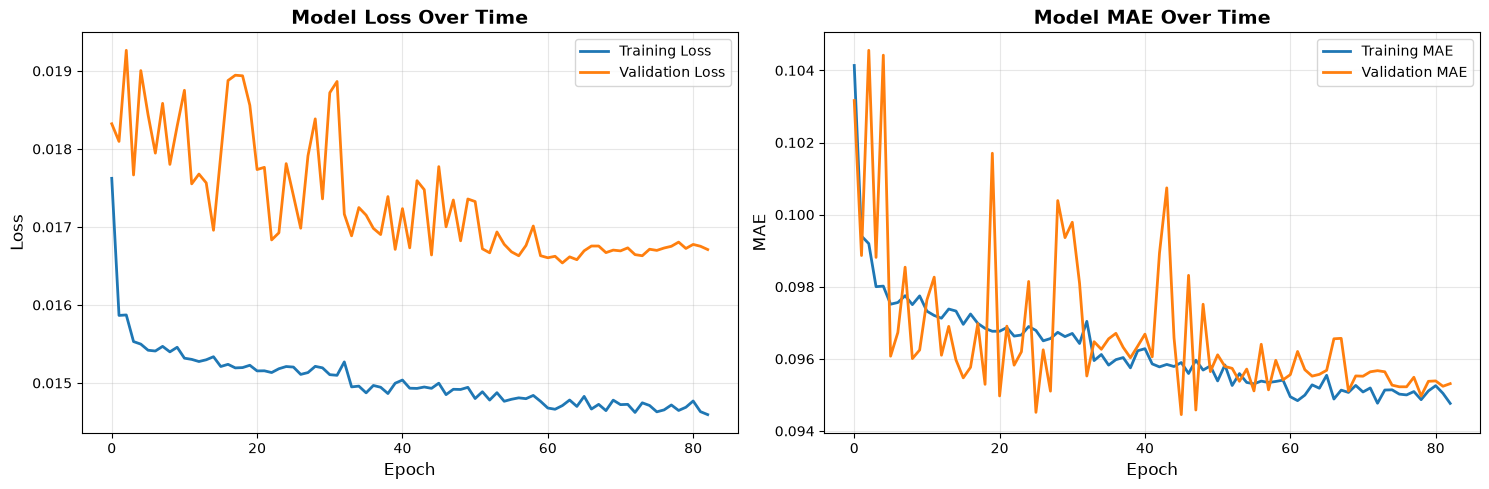

Training history plot saved as 'training_history.png'


In [14]:
# Plot loss curves
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Model Loss Over Time', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# MAE
axes[1].plot(history.history['mae'], label='Training MAE', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('MAE', fontsize=12)
axes[1].set_title('Model MAE Over Time', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("Training history plot saved as 'training_history.png'")

## Evaluate the model

In [15]:
# Evaluate on validation set (custom model returns a metrics dict)
val_metrics = model.evaluate(X_val, y_val, verbose=0, return_dict=True)

print("=" * 60)
print("VALIDATION METRICS")
print("=" * 60)
for k, v in val_metrics.items():
    print(f"{k:16s}: {v:.6f}")
if 'mse' in val_metrics:
    print(f"{'rmse':16s}: {np.sqrt(val_metrics['mse']):.6f}")
print("=" * 60)

val_loss = val_metrics.get('loss', float('nan'))
val_mae = val_metrics.get('mae', float('nan'))
val_mse = val_metrics.get('mse', float('nan'))


VALIDATION METRICS
data_loss       : 0.015933
loss            : 0.015987
mae             : 0.095700
mse             : 0.015799
physics_loss    : 0.005443
rmse            : 0.125694


## Make predictions and visualize

In [16]:
# Make predictions on validation set
y_pred = model.predict(X_val, verbose=0)

# Denormalize for visualization
y_val_actual = scaler_temp.inverse_transform(y_val)
y_pred_actual = scaler_temp.inverse_transform(y_pred)

print(f"Predictions shape: {y_pred_actual.shape}")
print(f"Actual values shape: {y_val_actual.shape}")

Predictions shape: (2010, 1)
Actual values shape: (2010, 1)


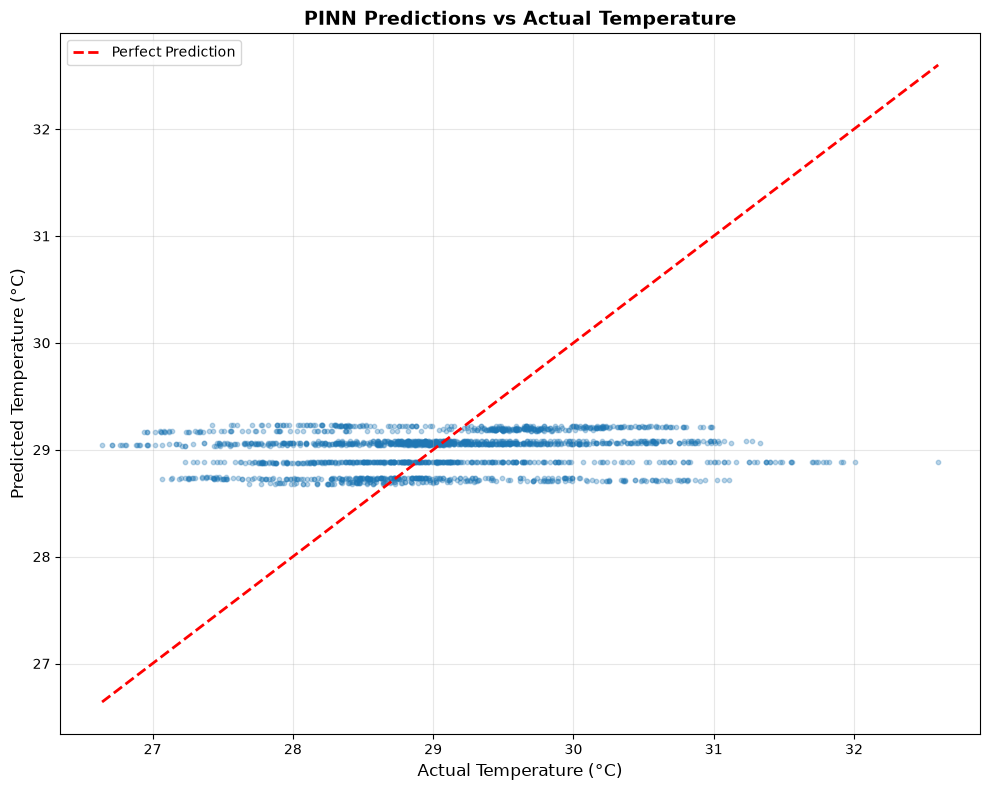

Prediction plot saved as 'predictions_vs_actual.png'


In [17]:
# Scatter plot: Predicted vs Actual
plt.figure(figsize=(10, 8))
plt.scatter(y_val_actual, y_pred_actual, alpha=0.3, s=10)
plt.plot([y_val_actual.min(), y_val_actual.max()], 
         [y_val_actual.min(), y_val_actual.max()], 
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Temperature (°C)', fontsize=12)
plt.ylabel('Predicted Temperature (°C)', fontsize=12)
plt.title('PINN Predictions vs Actual Temperature', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('predictions_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

print("Prediction plot saved as 'predictions_vs_actual.png'")

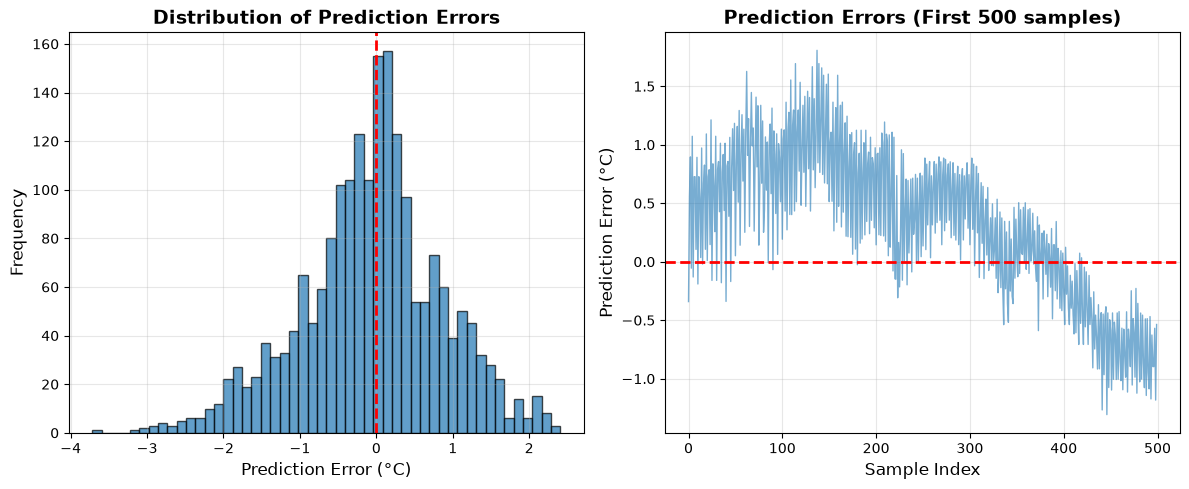

Error analysis plot saved as 'error_analysis.png'


In [18]:
# Calculate prediction errors
errors = y_pred_actual - y_val_actual

plt.figure(figsize=(12, 5))

# Error distribution
plt.subplot(1, 2, 1)
plt.hist(errors, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Prediction Error (°C)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Prediction Errors', fontsize=14, fontweight='bold')
plt.axvline(0, color='r', linestyle='--', linewidth=2)
plt.grid(True, alpha=0.3)

# Error over sample index
plt.subplot(1, 2, 2)
plt.plot(errors[:500], alpha=0.6, linewidth=1)
plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('Prediction Error (°C)', fontsize=12)
plt.title('Prediction Errors (First 500 samples)', fontsize=14, fontweight='bold')
plt.axhline(0, color='r', linestyle='--', linewidth=2)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Error analysis plot saved as 'error_analysis.png'")

In [19]:
# Print error statistics
print("\n" + "="*60)
print("ERROR STATISTICS (Actual Temperature Scale)")
print("="*60)
print(f"Mean Error:       {np.mean(errors):.4f} °C")
print(f"Std Error:        {np.std(errors):.4f} °C")
print(f"MAE:              {np.mean(np.abs(errors)):.4f} °C")
print(f"RMSE:             {np.sqrt(np.mean(errors**2)):.4f} °C")
print(f"Max Error:        {np.max(np.abs(errors)):.4f} °C")
print(f"95th Percentile:  {np.percentile(np.abs(errors), 95):.4f} °C")
print("="*60)


ERROR STATISTICS (Actual Temperature Scale)
Mean Error:       -0.0709 °C
Std Error:        0.9262 °C
MAE:              0.7072 °C
RMSE:             0.9289 °C
Max Error:        3.7159 °C
95th Percentile:  1.8972 °C


## Save the trained model

In [20]:
# Save the inference backbone (plain Keras model for forecaster.py)
model.backbone.save('pinn_model_final.h5')
print("Final backbone saved as 'pinn_model_final.h5'")


Final backbone saved as 'pinn_model_final.h5'


In [21]:
# Also save backbone in TensorFlow SavedModel format
model.backbone.export('pinn_model_saved')
print("Backbone exported in TensorFlow SavedModel format at 'pinn_model_saved/'")


INFO:tensorflow:Assets written to: pinn_model_saved\assets


INFO:tensorflow:Assets written to: pinn_model_saved\assets


Saved artifact at 'pinn_model_saved'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 3), dtype=tf.float32, name='input')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2237739436944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2237739438096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2237739437136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2237739436560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2237739436368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2237739438480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2237739437328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2237739438672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2237739437520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2237739439632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2237739439440: TensorSpec(shape=(), dtype=tf.resour

In [22]:
# Save training history
history_df = pd.DataFrame(history.history)
history_df.to_csv('training_history.csv', index=False)
print("Training history saved as 'training_history.csv'")

Training history saved as 'training_history.csv'


## Test the model with a single prediction

In [23]:
# Test with a single point
test_point = X_val[0:1]  # Take first validation point
test_actual = y_val_actual[0]

# Denormalize input
test_lat = scaler_lat.inverse_transform([[test_point[0, 0]]])[0, 0]
test_lon = scaler_lon.inverse_transform([[test_point[0, 1]]])[0, 0]
test_time = scaler_time.inverse_transform([[test_point[0, 2]]])[0, 0]

# Predict
prediction = model.predict(test_point, verbose=0)
prediction_actual = scaler_temp.inverse_transform(prediction)[0, 0]

print("\n" + "="*60)
print("SINGLE POINT TEST")
print("="*60)
print(f"Input Location:")
print(f"  Latitude:  {test_lat:.4f}°")
print(f"  Longitude: {test_lon:.4f}°")
print(f"  Time:      {test_time:.1f} days from start")
print(f"\nPrediction:")
print(f"  Actual Temperature:    {test_actual[0]:.4f} °C")
print(f"  Predicted Temperature: {prediction_actual:.4f} °C")
print(f"  Error:                 {abs(test_actual[0] - prediction_actual):.4f} °C")
print("="*60)


SINGLE POINT TEST
Input Location:
  Latitude:  6.1250°
  Longitude: 80.0750°
  Time:      3215.0 days from start

Prediction:
  Actual Temperature:    29.4200 °C
  Predicted Temperature: 29.0792 °C
  Error:                 0.3408 °C


## Summary

In [24]:
print("\n" + "="*60)
print("PINN MODEL TRAINING COMPLETE")
print("="*60)
print(f"Model Architecture:")
print(f"  Input: 3 features (lat, lon, time)")
print(f"  Hidden Layers: [128, 128, 64, 64, 32]")
print(f"  Output: 1 (temperature)")
print(f"  Total Parameters: {model.count_params():,}")
print(f"\nTraining:")
print(f"  Epochs completed: {len(history.history['loss'])}")
print(f"  Best validation loss: {min(history.history['val_loss']):.6f}")
print(f"  Final validation MAE: {val_mae:.6f}")
print(f"\nFiles saved:")
print(f"  - pinn_model_final.h5")
print(f"  - pinn_model_best.h5")
print(f"  - pinn_model_saved/ (TensorFlow format)")
print(f"  - training_history.csv")
print(f"  - training_history.png")
print(f"  - predictions_vs_actual.png")
print(f"  - error_analysis.png")
print(f"\nReady for visualization and deployment!")
print("="*60)


PINN MODEL TRAINING COMPLETE
Model Architecture:
  Input: 3 features (lat, lon, time)
  Hidden Layers: [128, 128, 64, 64, 32]
  Output: 1 (temperature)
  Total Parameters: 33,217

Training:
  Epochs completed: 83
  Best validation loss: 0.016539
  Final validation MAE: 0.095700

Files saved:
  - pinn_model_final.h5
  - pinn_model_best.h5
  - pinn_model_saved/ (TensorFlow format)
  - training_history.csv
  - training_history.png
  - predictions_vs_actual.png
  - error_analysis.png

Ready for visualization and deployment!
